# Sex Hamstrings-Quadriceps (SHQ) Ratio Primary Analysis
Updated 04/08/2026

-----------
## Cell 1 - Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from tkinter import Tk
from tkinter.filedialog import askdirectory

print(f'{datetime.now()} - Imports OK')

# Also defining custom plot theme here
custom_theme = {"axes.spines.right": False, 
                "axes.spines.top": False,
                "axes.titlelocation": "left", 
                "axes.titley": 1,
                "font.weight":"bold", 
                "axes.titlesize": "x-large", 
                "axes.labelsize": "x-large",
                "axes.titleweight": "bold", 
                "axes.labelweight": 'bold'}

plt.rcParams.update({
    **custom_theme,
    'figure.facecolor': 'white',  # transparent background for plots
    'axes.labelcolor': 'black',   # White axes labels
    'axes.edgecolor': 'black',    # White axes edge color
    'xtick.color': 'black',       # White x-axis tick labels
    'ytick.color': 'black',       # white y-axis tick labels
    "axes.titlecolor": "black"    # white title label
})

2026-04-09 09:42:38.505259 - Imports OK


------------
## Cell 2 - Select Data Folder 
Select the folder in which all the processed data are stored. All files (MVIC, isokinetic, cuts, and drops) should be stored in the exact same folder. The code below will sort them into separate lists (e.g., a list for the MVIC files etc.).

In [3]:
# Helper function to choose the folder in which the data files are stored.
def pick_directory(prompt="Select Participant's Data Folder"):
    root = Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    root.update()
    folder = askdirectory(title=prompt, parent = root)
    root.destroy()
    return folder

# Choose the primary data folder
primary_folder = pick_directory() 

# Full list of the primary filfes
primary_files = os.listdir(primary_folder) 

# Sort the OpenCap files into separate lists consisting of just the sl_drops, the dl_drops, cuts
sl_drops = [f for f in primary_files if "R_drop" in f or "L_drop" in f]
dl_drops = [f for f in primary_files if "Double_drop" in f]
cuts = [f for f in primary_files if "cut" in f]

# Sort the dynamometer files into separate lists for MVIC (isometric) and isokinetic (60 deg and 180 deg)
mvics = [f for f in primary_files if "KE" in f or "KF" in f]
isokinetics = [f for f in primary_files if "60deg" in f or "180deg" in f]

# Sanity check - print all results of the lists in an organized way
print(f'{len(primary_files)} files found in {primary_folder}:')
print(' \u2192 SL drop files:')
for f in sl_drops:  
    print(f'     • {f}')
print('\n \u2192 DL drop files:')
for f in dl_drops:
    print(f'     • {f}')
print('\n \u2192 Cut files:')
for f in cuts:
    print(f'     • {f}')
print('\n \u2192 MVIC files:')
for f in mvics:
    print(f'     • {f}')
print('\n \u2192 Isokinetic files:')
for f in isokinetics:
    print(f'     • {f}')

31 files found in E:/Research/0-Mentoring/MoosbruggerJ/SHQ/Data Collection/SHQ001/Full Data:
 → SL drop files:
     • SHQ001_OpenCap_L_drop_1.csv
     • SHQ001_OpenCap_L_drop_2.csv
     • SHQ001_OpenCap_L_drop_3.csv
     • SHQ001_OpenCap_R_drop_1.csv
     • SHQ001_OpenCap_R_drop_2.csv
     • SHQ001_OpenCap_R_drop_3.csv

 → DL drop files:
     • SHQ001_OpenCap_Double_drop_1.csv
     • SHQ001_OpenCap_Double_drop_2.csv
     • SHQ001_OpenCap_Double_drop_3.csv

 → Cut files:
     • SHQ001_OpenCap_L_cut_1.csv
     • SHQ001_OpenCap_L_cut_2.csv
     • SHQ001_OpenCap_L_cut_3.csv
     • SHQ001_OpenCap_R_cut_1.csv
     • SHQ001_OpenCap_R_cut_2.csv
     • SHQ001_OpenCap_R_cut_3.csv

 → MVIC files:
     • SHQ001_LEFT_KE1.txt
     • SHQ001_LEFT_KE2.txt
     • SHQ001_LEFT_KE3.txt
     • SHQ001_LEFT_KF1.txt
     • SHQ001_LEFT_KF2.txt
     • SHQ001_LEFT_KF3.txt
     • SHQ001_RIGHT_KE1.txt
     • SHQ001_RIGHT_KE2.txt
     • SHQ001_RIGHT_KE3.txt
     • SHQ001_RIGHT_KF1.txt
     • SHQ001_RIGHT_KF2.txt
   

----
## Cell 3 - Read in SL Drops files
This will read in the single-leg (SL) drops files and save them in a Python dictionary. All that means is it is allocated to save the file name (we adjust the file name to something cleaner in the code) and the file's associated data in a clean way. 

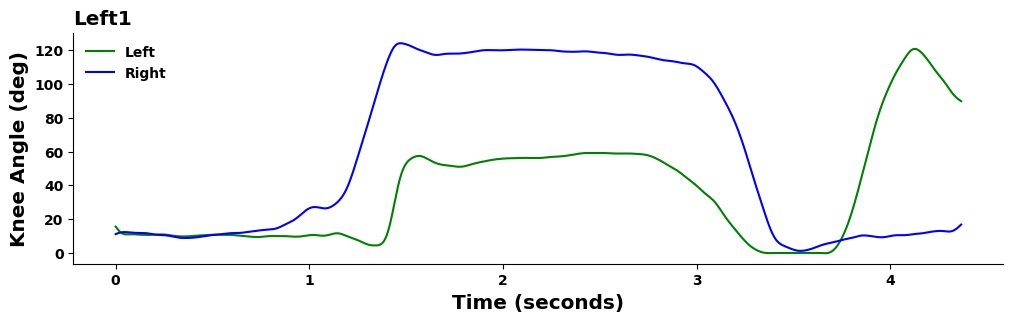

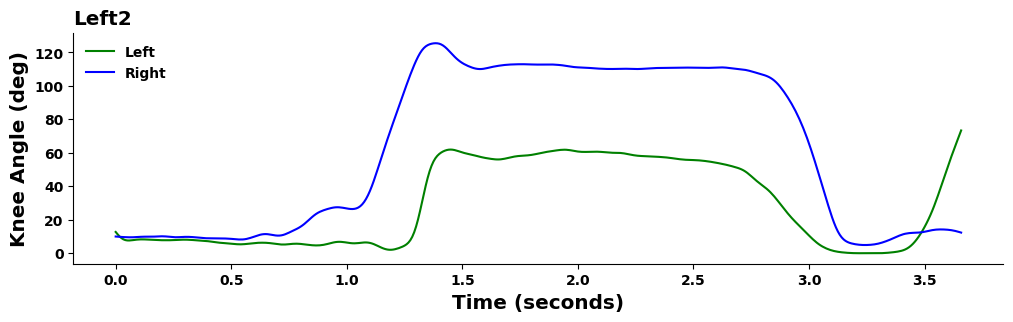

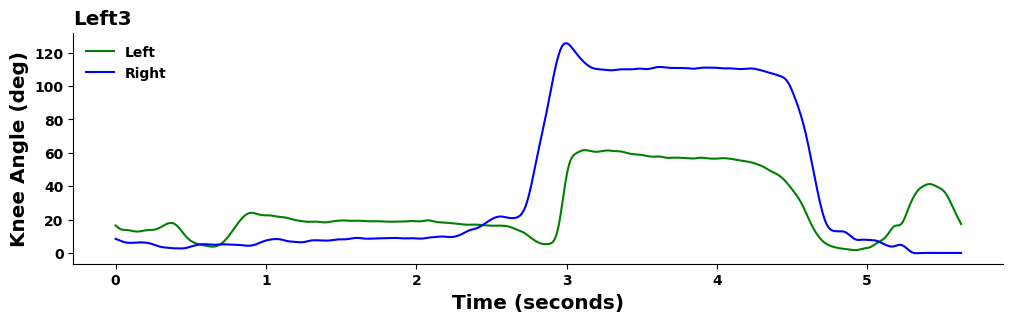

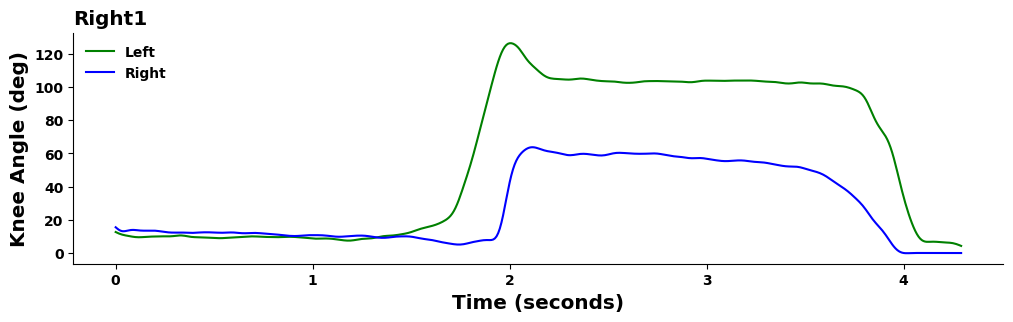

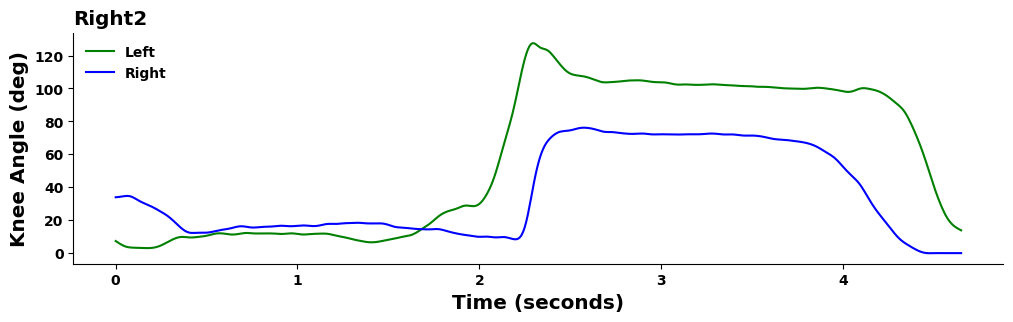

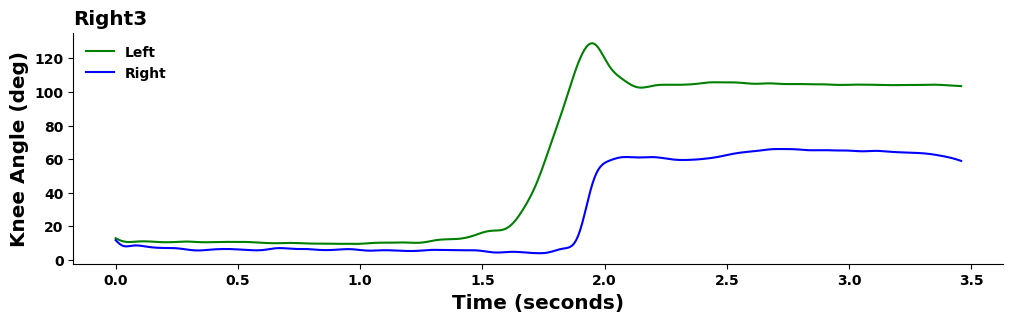

In [ ]:
# Helper function 1 - read in the OpenCap file and store it in a dataframe (Python's version of Excel spreadsheets)
def read_opencap_files(file_name):
    # State full file name
    full_file_name = os.path.join(primary_folder, file_name)
    # Read in data using panda's read_csv function
    dat = pd.read_csv(full_file_name)
    # Return the data we read in
    return dat

# Helper function 2 - Clean the file name to remove the extension (.csv), the ID number (since you will do this on a subject-by-subject basis), and return a clean version of the name. 
def format_filename(file_name):
    # Remove .csv
    name = file_name.replace(".csv", "")
    # Split components
    parts = name.split("_")
    # Determine sides
    if "L" in parts:
        side = "Left"
    elif "R" in parts:
        side = "Right"
    # Determine rep number
    trial = parts[-1]
    # Return cleanly formatted file name
    return f'{side}{trial}'

# Initialize an empty dictionary to store the results in
sl_drops_dat = {}

# Primary for loop, go through each separate file and save it in the dictionary under the key of the cleaned name. 
for sl_drop_file in sl_drops:
    # First, format the filename correctly 
    clean_name = format_filename(sl_drop_file)
    # Save the data to the dictionary
    sl_drops_dat[clean_name] = read_opencap_files(sl_drop_file)


for sl_drop_file in sl_drops_dat:
    dat = sl_drops_dat[sl_drop_file]
    time_s = dat['time_s']
    l_angle = dat['left_knee_angle_deg']
    r_angle = dat['right_knee_angle_deg']

    plt.figure(figsize = (12, 3))
    plt.plot(time_s, l_angle, color = 'green', label = 'Left')
    plt.plot(time_s, r_angle, color = 'blue', label = 'Right')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Knee Angle (deg)')
    plt.title(sl_drop_file)
    plt.legend(frameon = False, loc = 'upper left')

In [40]:
sl_drops_contacts = pd.DataFrame({
        'Trial': ['Left1', 'Left2', 'Left3', 'Right1', 'Right2', 'Right3'],
        'IC_Frame': [165, 152, 349, 232, 269, 225]})

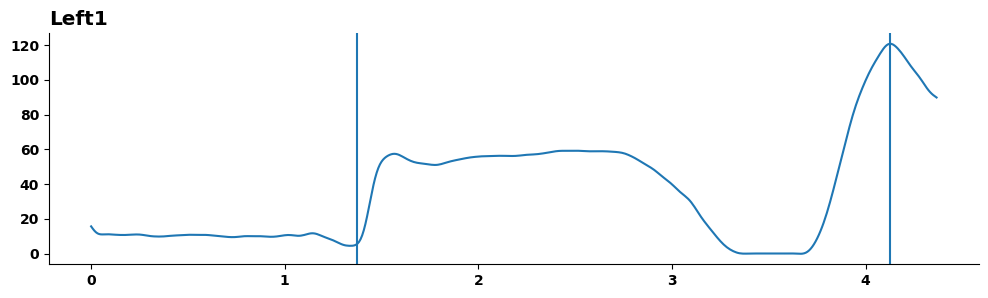

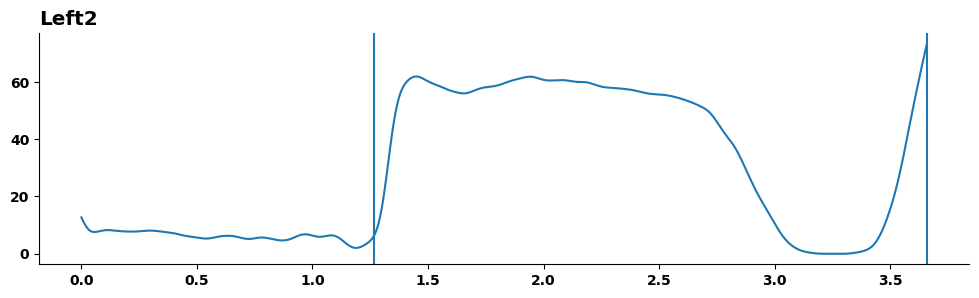

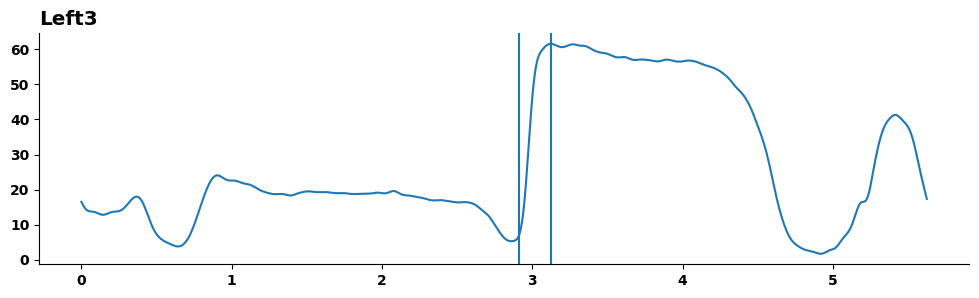

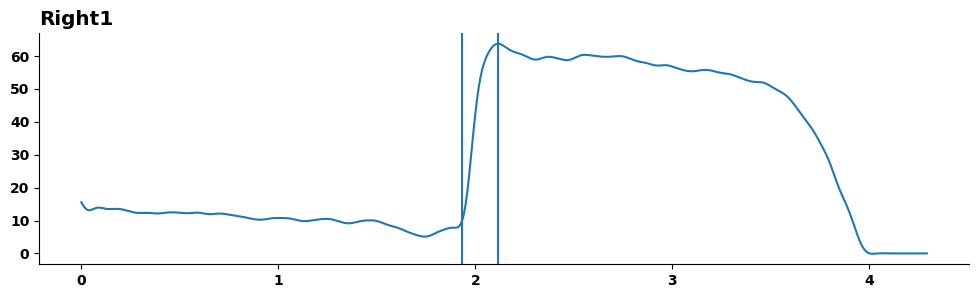

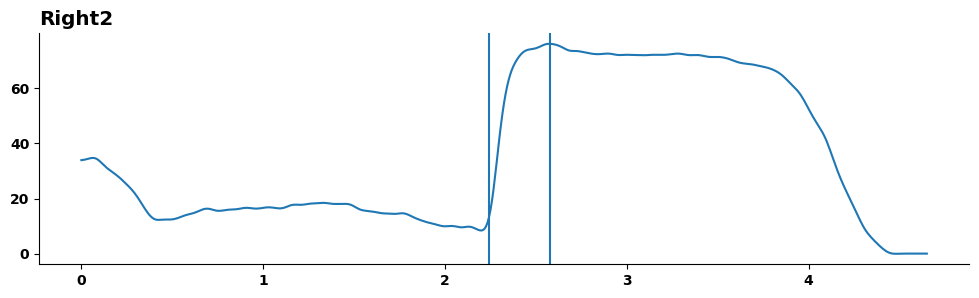

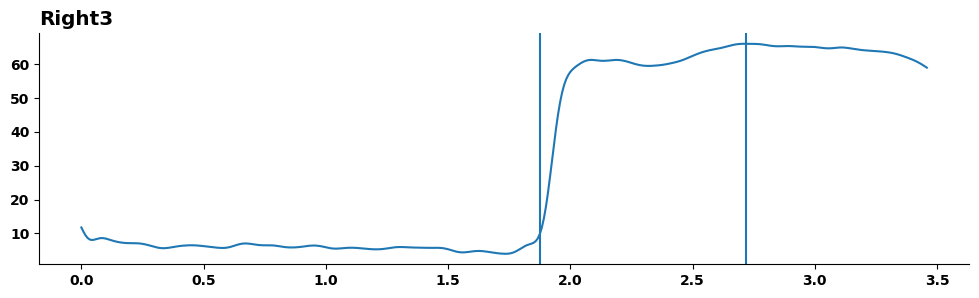

In [58]:
ic_lookup = {
    f"{row.Trial[:-1]}{row.Trial[-1]}": row.IC_Frame
    for _, row in sl_drops_contacts.iterrows()
}
ic_lookup

def plot_with_correct_leg(file_name):
    if "Left" in file_name:
        leg = "left_knee_angle_deg"
    else:
        leg = 'right_knee_angle_deg'
    
    dat = sl_drops_dat[file_name]

    time_s = dat['time_s']
    knee_angle = dat[leg]

    ic_frame = ic_lookup[file_name]
    ic_time = time_s[ic_frame]

    ic_knee_angle = knee_angle[ic_frame]
    max_knee_angle_index = knee_angle.idxmax()
    max_knee_angle_time = time_s[max_knee_angle_index]


    plt.figure(figsize = (12, 3))
    plt.plot(time_s, knee_angle)
    plt.title(file_name)
    plt.axvline(ic_time)
    plt.axvline(max_knee_angle_time)

for f in sl_drops_dat:
    plot_with_correct_leg(f)


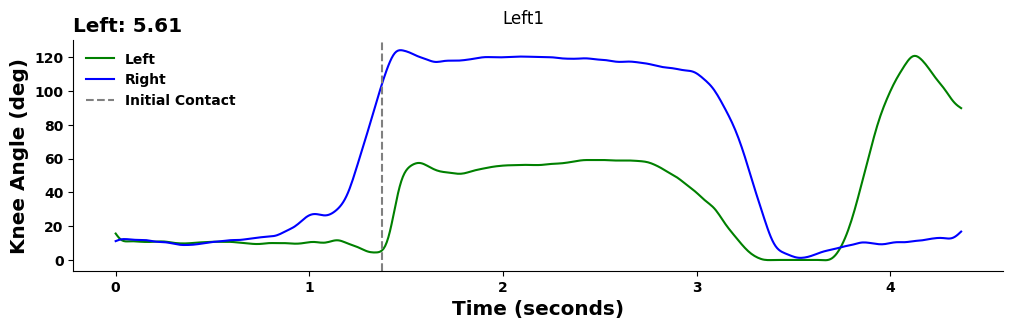

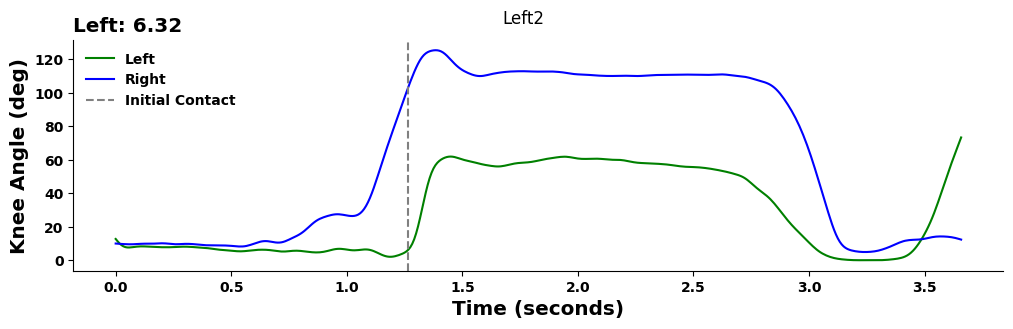

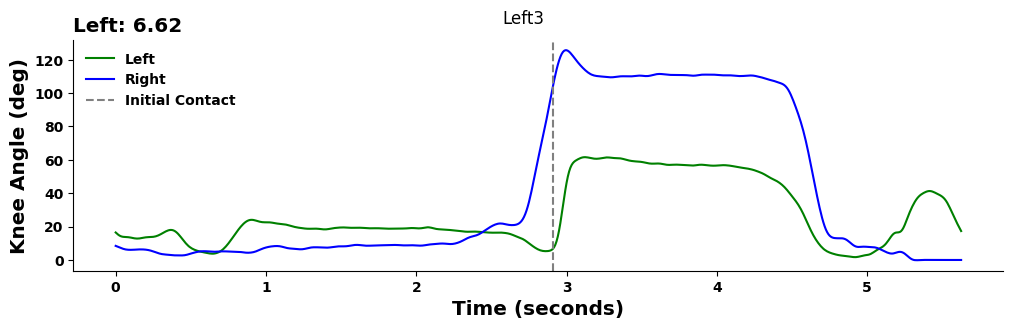

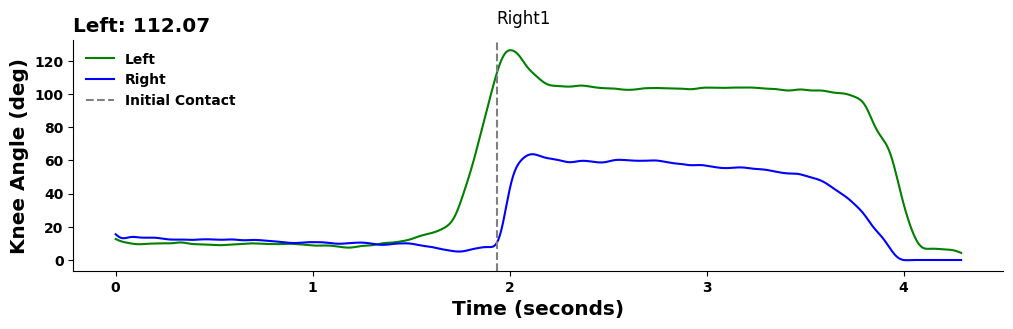

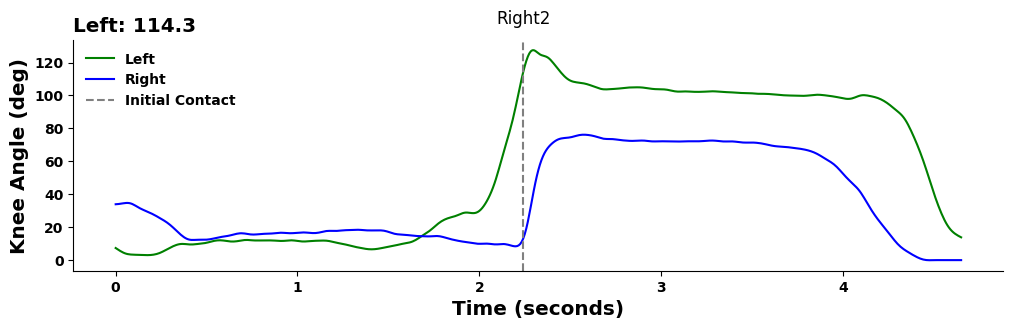

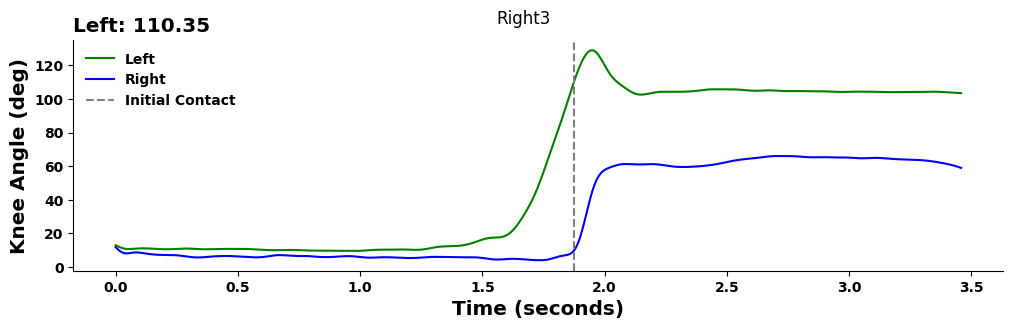

In [56]:

for sl_drop_file in sl_drops_dat:
    dat = sl_drops_dat[sl_drop_file]

    time_s = dat['time_s']
    l_angle = dat['left_knee_angle_deg']
    r_angle = dat['right_knee_angle_deg']

    ic_frame = ic_lookup[sl_drop_file]
    ic_time = time_s[ic_frame]

    l_ic = round(l_angle[ic_frame], 2) 
    r_ic = r_angle[ic_frame]

    plt.figure(figsize = (12, 3))
    plt.plot(time_s, l_angle, color = 'green', label = 'Left')
    plt.plot(time_s, r_angle, color = 'blue', label = 'Right')
    plt.axvline(ic_time, ls = '--', color = 'grey', label  = 'Initial Contact')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Knee Angle (deg)')
    plt.suptitle(sl_drop_file)
    plt.title(f'Left: {l_ic}')
    plt.legend(frameon = False, loc = 'upper left')